# 1. Imports and visualization settings

In [1]:
from pathlib import Path
from src.io import build_metadata
from src.cleaning_metadata import clean_metadata
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import contextily as ctx
from adjustText import adjust_text
import matplotlib as mpl
import pandas as pd
import numpy as np
from itertools import combinations
from scipy import stats
from IPython.display import display
from src.plot_settings import set_plot_style
colors = set_plot_style()

# 2. Data loading

In [2]:
zip_path = Path("..") / "data" / "raw" / "query.zip"
df_meta = build_metadata(zip_path)

In [3]:
# Figures output directory
FIGURES_DIR = Path('../figures/01_metadata')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 3. Metadata exploration

In [4]:
# Shape
print("Metadata DataFrame shape:", df_meta.shape)

# Columns
print("\nMetadata columns:")
for col in df_meta.columns:
    print(f"  {col}")

# Data types
print("\nColumn types distribution:")
print(df_meta.dtypes.value_counts())

# Missing values
print("Missing values (NaN) in raw df_meta:")
print(df_meta.isnull().sum().sum())

# Sample
print("\nFirst 2 rows:")
print(df_meta.head(2).to_dict())

Metadata DataFrame shape: (66, 65)

Metadata columns:
  file
  EVENT_NAME
  EVENT_ID
  EVENT_DATE_YYYYMMDD
  EVENT_TIME_HHMMSS
  EVENT_LATITUDE_DEGREE
  EVENT_LONGITUDE_DEGREE
  EVENT_DEPTH_KM
  HYPOCENTER_REFERENCE
  MAGNITUDE_W
  MAGNITUDE_W_REFERENCE
  MAGNITUDE_L
  MAGNITUDE_L_REFERENCE
  FOCAL_MECHANISM
  NETWORK
  STATION_CODE
  STATION_NAME
  STATION_LATITUDE_DEGREE
  STATION_LONGITUDE_DEGREE
  STATION_ELEVATION_M
  LOCATION
  SENSOR_DEPTH_M
  VS30_M/S
  SITE_CLASSIFICATION_EC8
  MORPHOLOGIC_CLASSIFICATION
  EPICENTRAL_DISTANCE_KM
  EARTHQUAKE_BACKAZIMUTH_DEGREE
  DATE_TIME_FIRST_SAMPLE_YYYYMMDD_HHMMSS
  DATE_TIME_FIRST_SAMPLE_PRECISION
  SAMPLING_INTERVAL_S
  NDATA
  DURATION_S
  STREAM
  UNITS
  INSTRUMENT
  INSTRUMENT_ANALOG/DIGITAL
  INSTRUMENTAL_FREQUENCY_HZ
  INSTRUMENTAL_DAMPING
  FULL_SCALE_G
  N_BIT_DIGITAL_CONVERTER
  PGA_CM/S^2
  TIME_PGA_S
  BASELINE_CORRECTION
  FILTER_TYPE
  FILTER_ORDER
  LOW_CUT_FREQUENCY_HZ
  HIGH_CUT_FREQUENCY_HZ
  LATE/NORMAL_TRIGGERED
  DATAB

`isnull()` returns 0 for all columns because missing values are encoded as empty strings `''` or the string `'None'`, not as `NaN`. This will be addressed in the preprocessing step.

# 4. Metadata preprocessing

In [5]:
df_meta_clean = clean_metadata(df_meta)

# 5. Post-preprocessing check (metadata)

Cleaned metadata shape: (66, 37)

Column types distribution:
object            17
float64           15
int64              3
datetime64[ns]     2
Name: count, dtype: int64


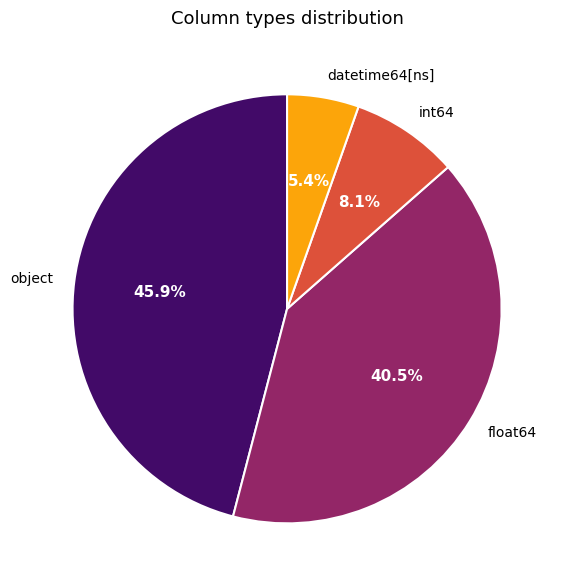


Missing values after preprocessing:
SITE_CLASSIFICATION_EC8    27.27
LOCATION                   22.73


In [6]:
# Shape after preprocessing
print("Cleaned metadata shape:", df_meta_clean.shape)

# Column types distribution
print("\nColumn types distribution:")
print(df_meta_clean.dtypes.value_counts())

# Pie chart of column types
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    df_meta_clean.dtypes.astype(str).value_counts(),
    labels=df_meta_clean.dtypes.astype(str).value_counts().index,
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
    startangle=90
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Column types distribution')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'column_types_distribution.pdf', bbox_inches='tight')
plt.show()

# Missing values after preprocessing
print("\nMissing values after preprocessing:")
missing = df_meta_clean.isnull().mean().sort_values(ascending=False) * 100
print(missing[missing > 0].round(2).to_string())

In [7]:
# Numerical columns
print("Numerical columns:")
print(df_meta_clean.select_dtypes(include=['float64', 'int64']).columns.tolist())

Numerical columns:
['EVENT_LATITUDE_DEGREE', 'EVENT_LONGITUDE_DEGREE', 'EVENT_DEPTH_KM', 'MAGNITUDE_W', 'STATION_LATITUDE_DEGREE', 'STATION_LONGITUDE_DEGREE', 'STATION_ELEVATION_M', 'SENSOR_DEPTH_M', 'EPICENTRAL_DISTANCE_KM', 'EARTHQUAKE_BACKAZIMUTH_DEGREE', 'SAMPLING_INTERVAL_S', 'NDATA', 'DURATION_S', 'PGA_CM/S^2', 'TIME_PGA_S', 'FILTER_ORDER', 'LOW_CUT_FREQUENCY_HZ', 'HIGH_CUT_FREQUENCY_HZ']


In [8]:
# Categorical columns
print("Categorical columns:")
print(df_meta_clean.select_dtypes(include='object').columns.tolist())

Categorical columns:
['file', 'EVENT_ID', 'HYPOCENTER_REFERENCE', 'MAGNITUDE_W_REFERENCE', 'FOCAL_MECHANISM', 'NETWORK', 'STATION_CODE', 'STATION_NAME', 'LOCATION', 'SITE_CLASSIFICATION_EC8', 'STREAM', 'INSTRUMENT', 'INSTRUMENT_ANALOG/DIGITAL', 'BASELINE_CORRECTION', 'FILTER_TYPE', 'LATE/NORMAL_TRIGGERED', 'PROCESSING']


# 6. Metadata Exploration (post-preprocessing)

In [9]:
# Check which columns have only one unique value
constant_cols = [col for col in df_meta_clean.columns if df_meta_clean[col].nunique() == 1]
print("Constant columns:", constant_cols)

Constant columns: ['EVENT_ID', 'EVENT_LATITUDE_DEGREE', 'EVENT_LONGITUDE_DEGREE', 'EVENT_DEPTH_KM', 'HYPOCENTER_REFERENCE', 'MAGNITUDE_W', 'MAGNITUDE_W_REFERENCE', 'FOCAL_MECHANISM', 'SAMPLING_INTERVAL_S', 'INSTRUMENT_ANALOG/DIGITAL', 'BASELINE_CORRECTION', 'FILTER_TYPE', 'FILTER_ORDER', 'LATE/NORMAL_TRIGGERED', 'PROCESSING', 'EVENT_DATE']


Since the dataset contains recordings from a single seismic event, many columns are constant across all files (e.g. event coordinates, magnitude, focal mechanism).  We create a reduced dataframe with only the varying columns, useful for analysis and visualization.

In [10]:
constant_cols = [col for col in df_meta_clean.columns if df_meta_clean[col].nunique() == 1]
df_meta_var = df_meta_clean.drop(columns=constant_cols)
print(df_meta_var.columns.tolist())
df_meta_var = df_meta_var.copy()
df_meta_var['PGA_CM/S^2'] = df_meta_var['PGA_CM/S^2'].abs()

['file', 'NETWORK', 'STATION_CODE', 'STATION_NAME', 'STATION_LATITUDE_DEGREE', 'STATION_LONGITUDE_DEGREE', 'STATION_ELEVATION_M', 'LOCATION', 'SENSOR_DEPTH_M', 'SITE_CLASSIFICATION_EC8', 'EPICENTRAL_DISTANCE_KM', 'EARTHQUAKE_BACKAZIMUTH_DEGREE', 'NDATA', 'DURATION_S', 'STREAM', 'INSTRUMENT', 'PGA_CM/S^2', 'TIME_PGA_S', 'LOW_CUT_FREQUENCY_HZ', 'HIGH_CUT_FREQUENCY_HZ', 'DATE_TIME_FIRST_SAMPLE']


## 6.1 Numerical and caterogical columns distributions

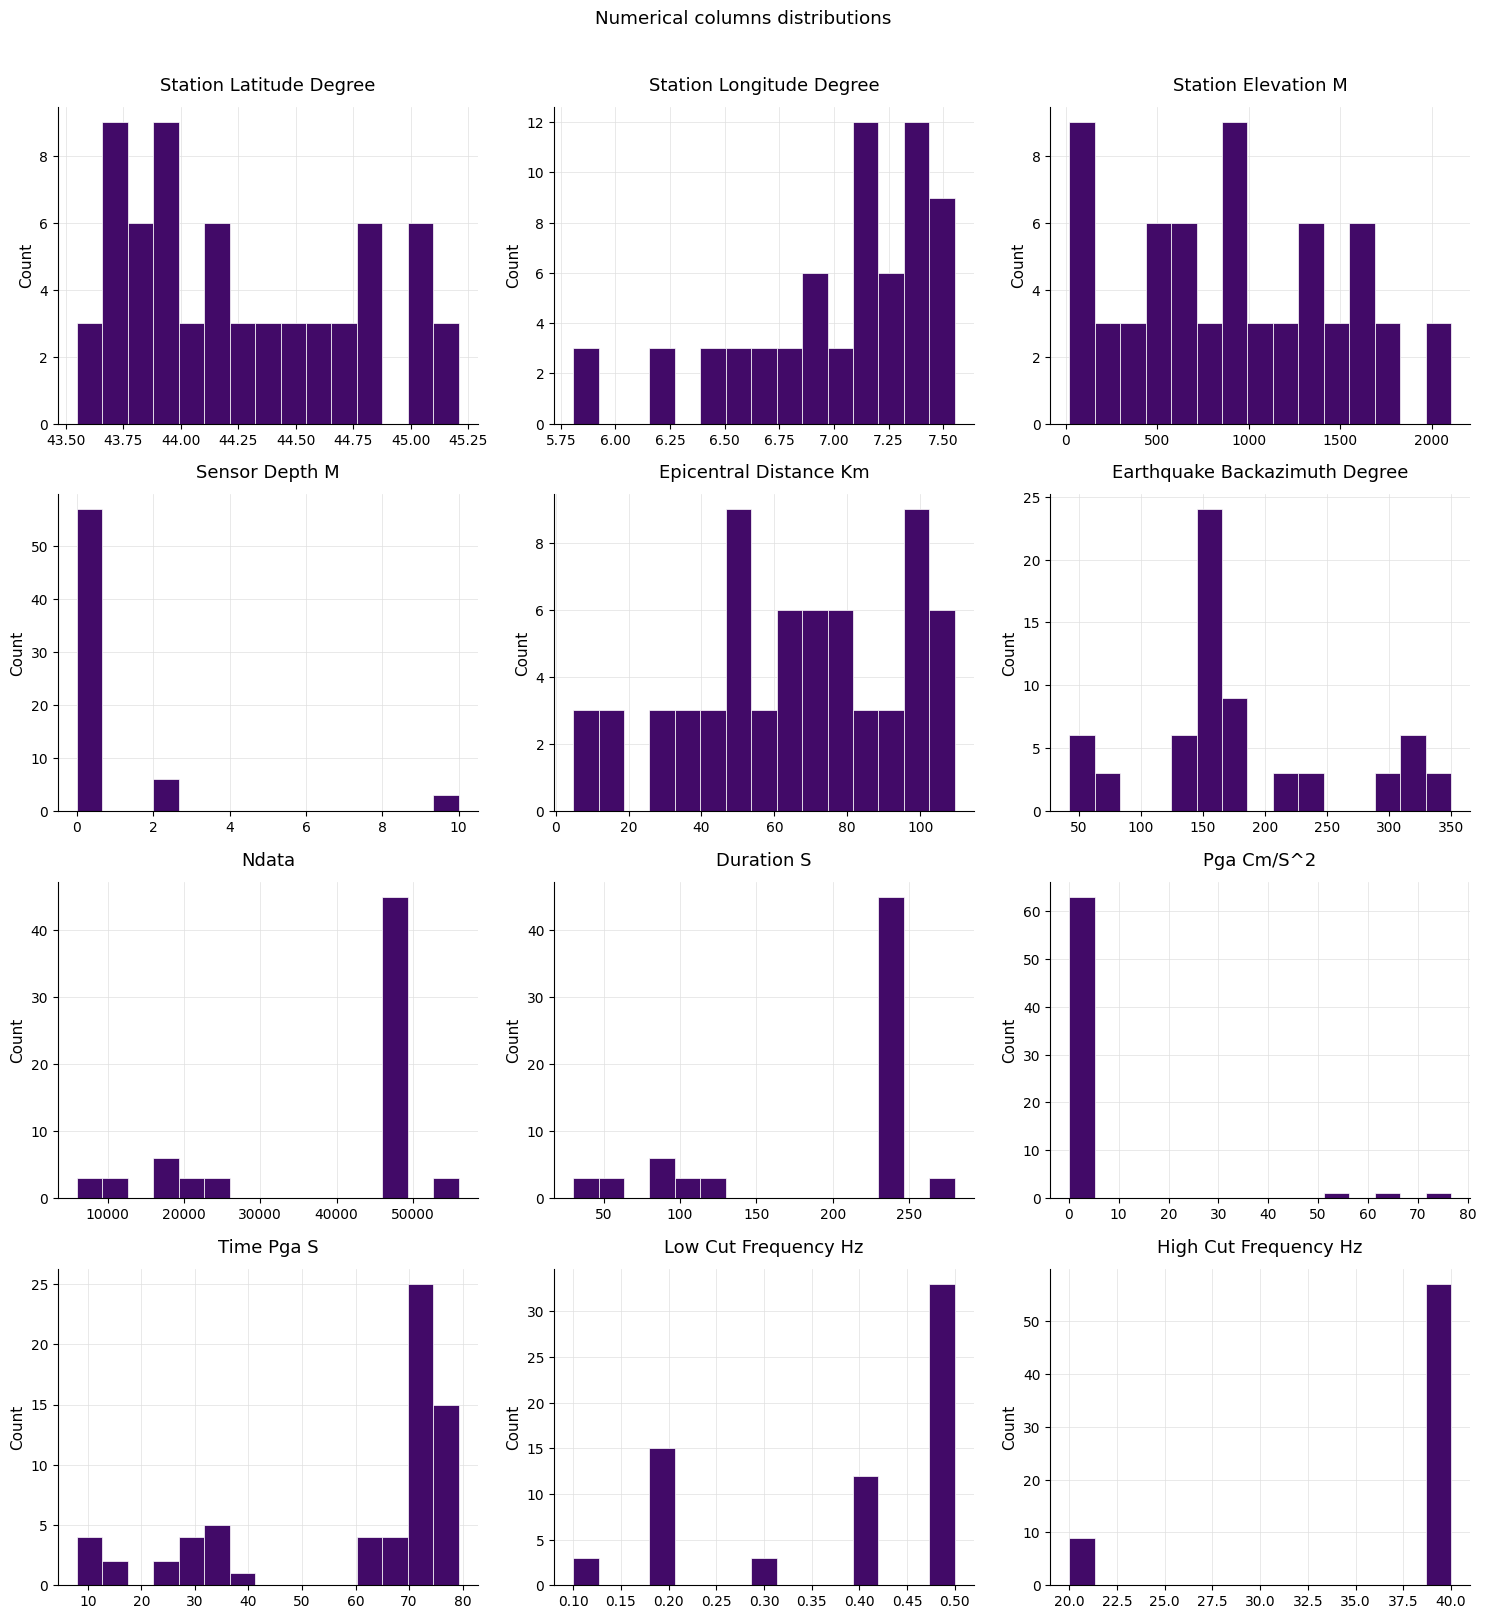

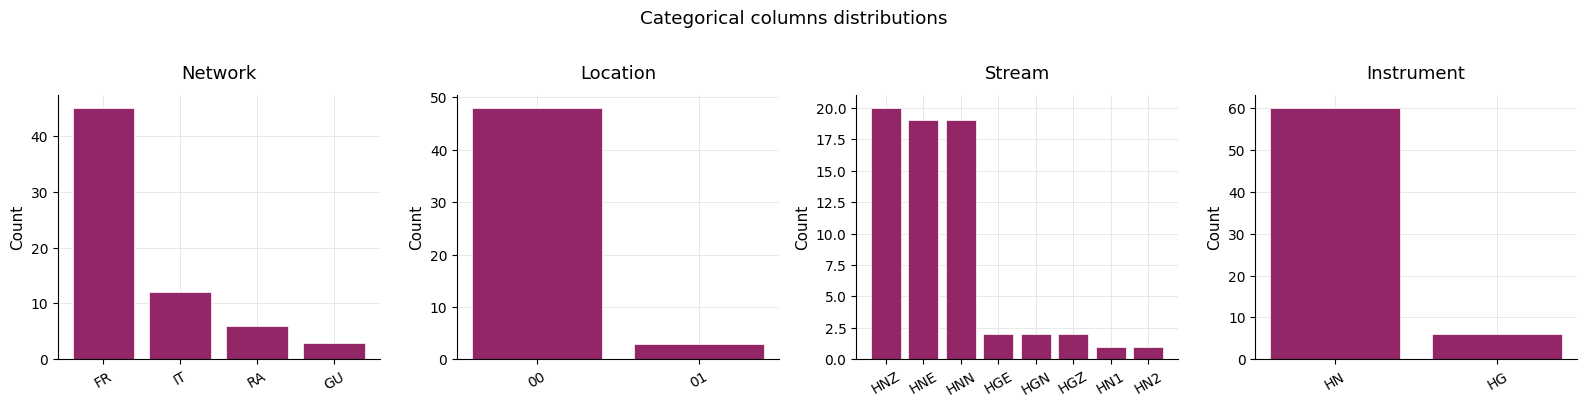

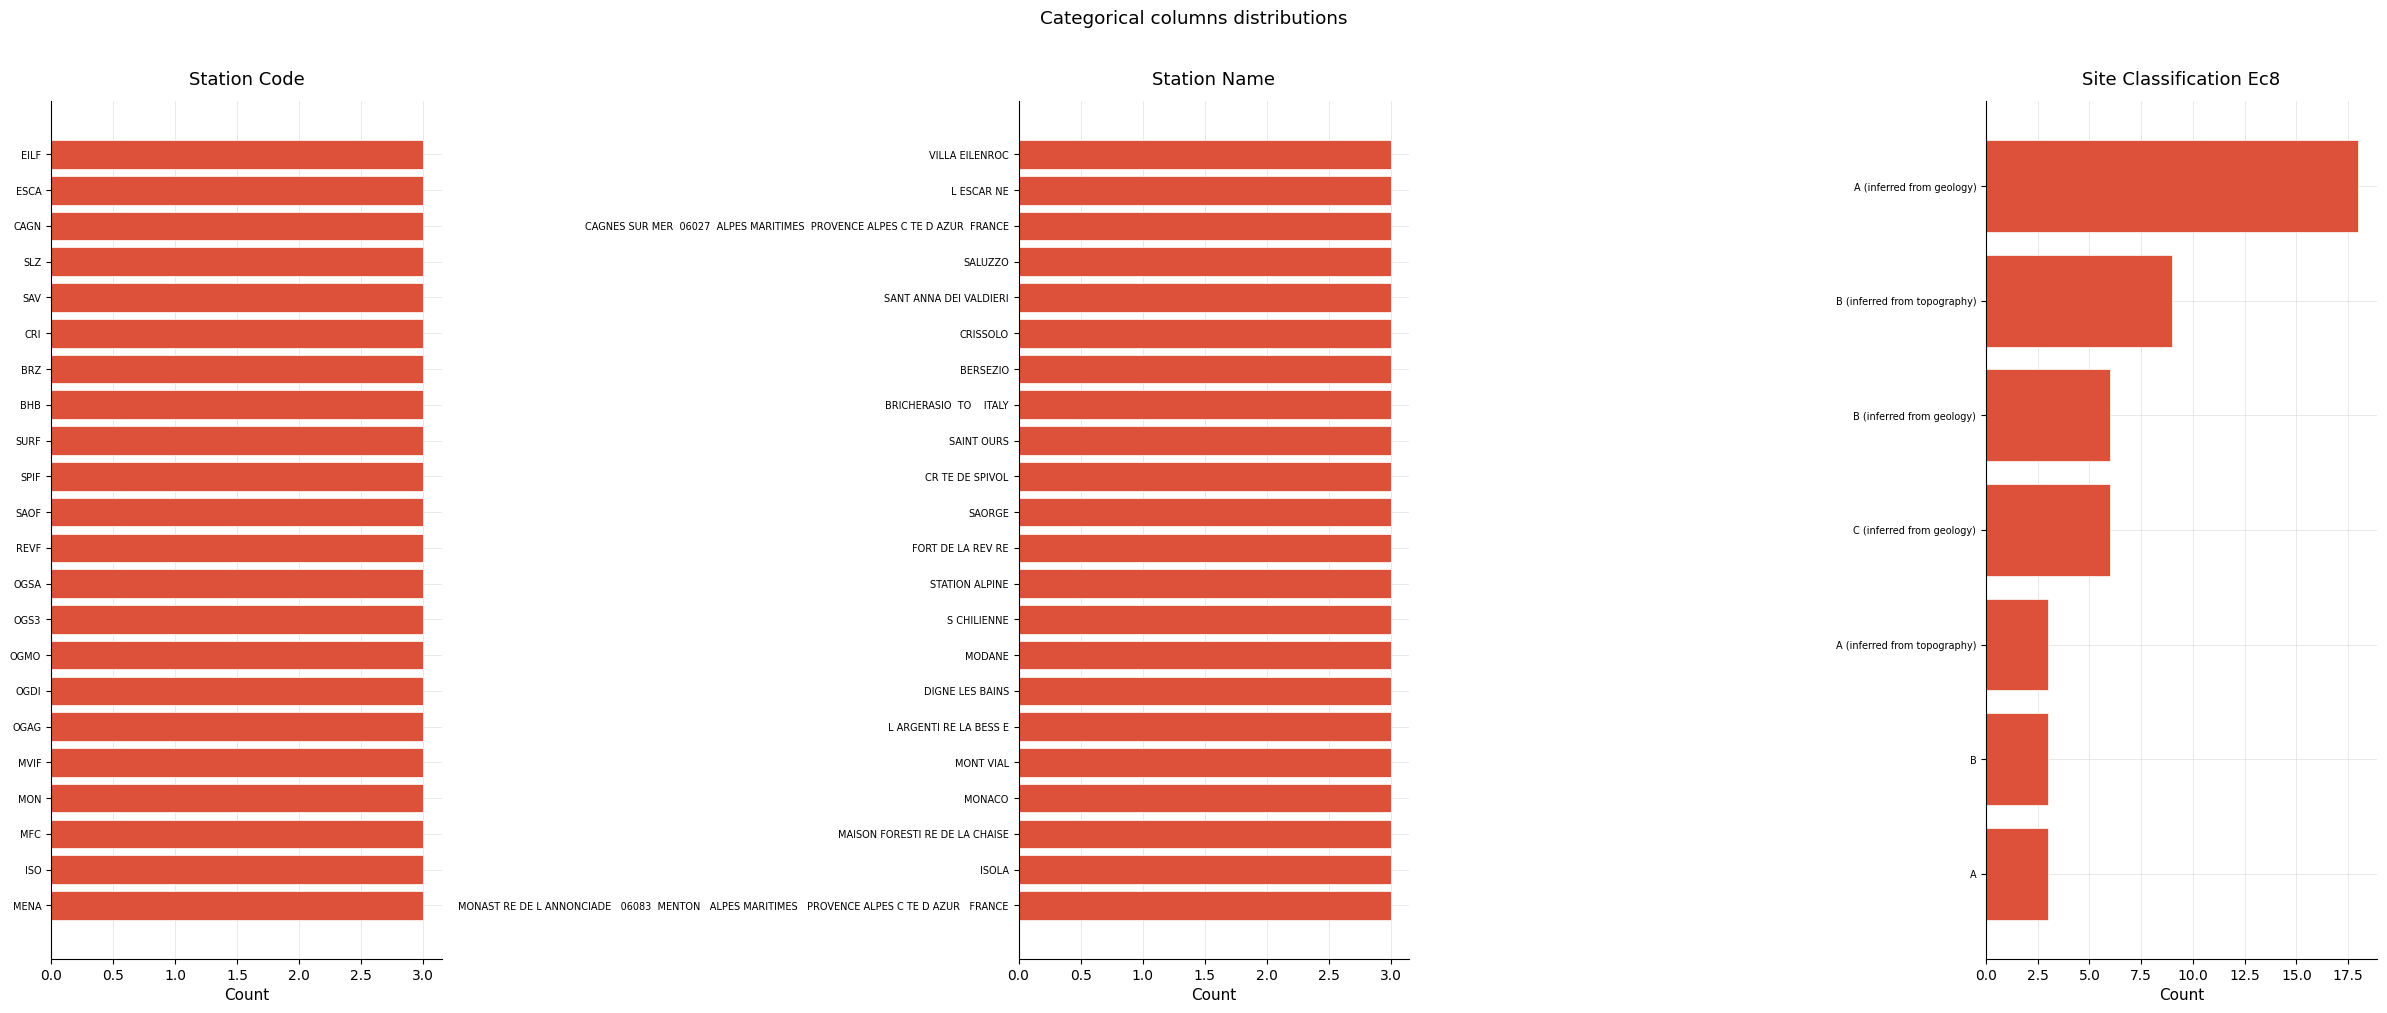

In [11]:
# ----------------
# NUMERICAL COLUMNS
# ----------------
num_cols = [
    'STATION_LATITUDE_DEGREE', 'STATION_LONGITUDE_DEGREE', 'STATION_ELEVATION_M',
    'SENSOR_DEPTH_M', 'EPICENTRAL_DISTANCE_KM', 'EARTHQUAKE_BACKAZIMUTH_DEGREE',
    'NDATA', 'DURATION_S', 'PGA_CM/S^2', 'TIME_PGA_S',
    'LOW_CUT_FREQUENCY_HZ', 'HIGH_CUT_FREQUENCY_HZ'
]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_meta_var[col].dropna(), bins=15, color=colors[0], edgecolor='white', linewidth=0.5)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical columns distributions', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'numerical_distributions.pdf', bbox_inches='tight')
plt.show()

# ----------------
# CATEGORICAL COLUMNS
# ----------------
cat_cols = ['NETWORK', 'STATION_CODE', 'STATION_NAME', 'LOCATION',
            'SITE_CLASSIFICATION_EC8', 'STREAM', 'INSTRUMENT']

few_cats = [c for c in cat_cols if df_meta_var[c].nunique() <= 8 and df_meta_var[c].str.len().max() <= 10]
many_cats = [c for c in cat_cols if df_meta_var[c].nunique() > 8 or df_meta_var[c].str.len().max() > 10]

# Bar chart vertical for few categories
fig, axes = plt.subplots(1, len(few_cats), figsize=(4 * len(few_cats), 4))
if len(few_cats) == 1:
    axes = [axes]

for i, col in enumerate(few_cats):
    counts = df_meta_var[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=colors[1], edgecolor='white', linewidth=0.5)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_ylabel('Count')
    if df_meta_var[col].str.len().max() > 10:
        axes[i].tick_params(axis='x', rotation=45, labelsize=6)
    else:
        axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical columns distributions', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'categorical_distributions_few.pdf', bbox_inches='tight')
plt.show()

# Bar chart horizontal for many categories
fig, axes = plt.subplots(1, len(many_cats), figsize=(8 * len(many_cats), 10))
if len(many_cats) == 1:
    axes = [axes]

for i, col in enumerate(many_cats):
    counts = df_meta_var[col].value_counts()
    axes[i].barh(counts.index, counts.values, color=colors[2], edgecolor='white', linewidth=0.5)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Count')
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].invert_yaxis()

plt.suptitle('Categorical columns distributions', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'categorical_distributions_many.pdf', bbox_inches='tight')
plt.show()

## 6.2 Correlation matrix

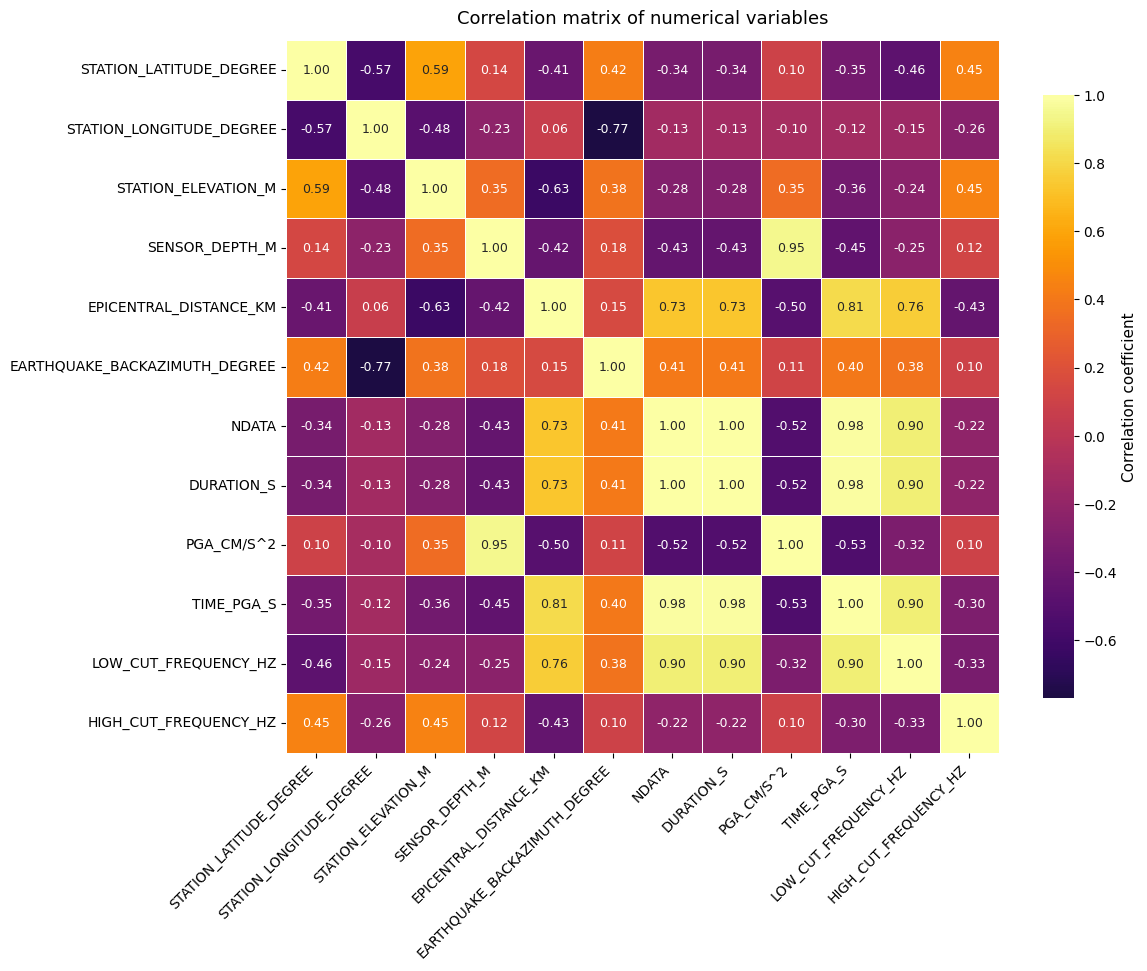

In [12]:
corr = df_meta_var.select_dtypes(include=['float64', 'int64']).corr().round(2)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='inferno',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 9},
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation coefficient'}
)
ax.grid(False)
ax.set_title('Correlation matrix of numerical variables')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_matrix.pdf', bbox_inches='tight')
plt.show()

## 6.3 Station map

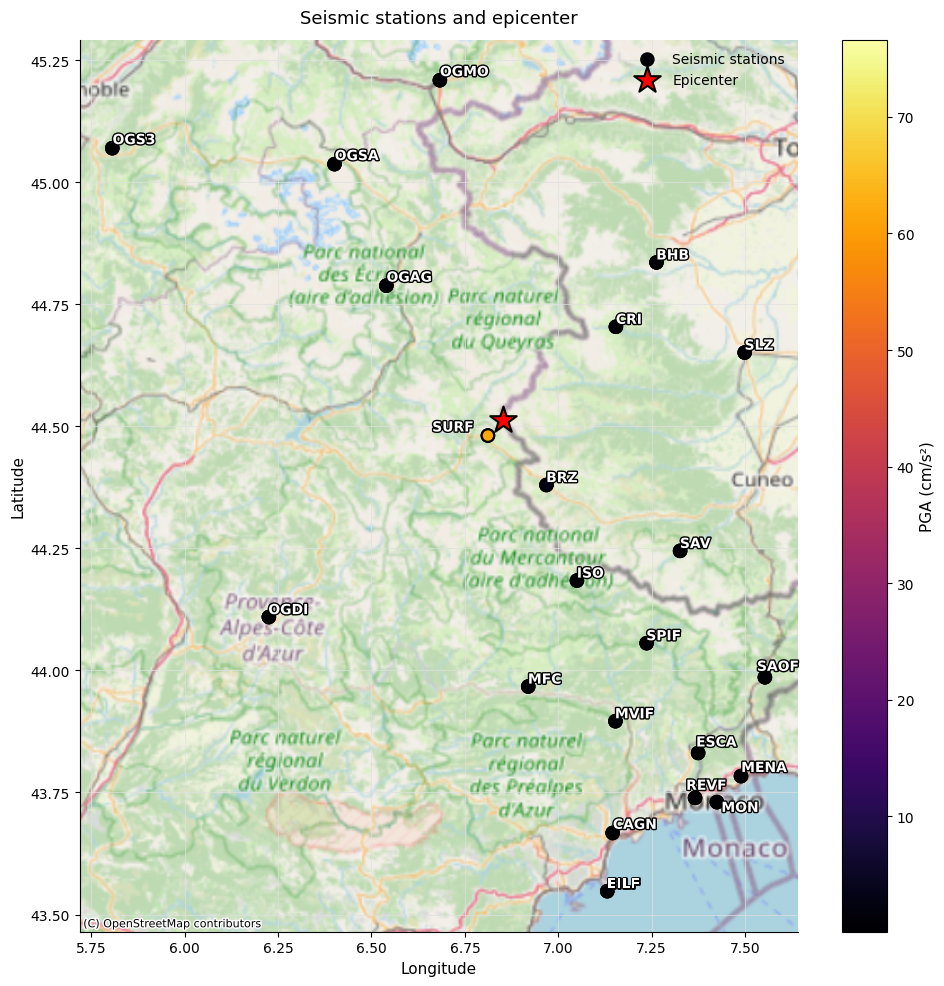

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot stations colored by PGA
scatter = ax.scatter(
    df_meta_var['STATION_LONGITUDE_DEGREE'],
    df_meta_var['STATION_LATITUDE_DEGREE'],
    c=df_meta_var['PGA_CM/S^2'],
    cmap='inferno',
    s=80,
    zorder=5,
    label='Seismic stations',
    edgecolors='black',
    linewidths=1.5
)

# Add station labels with adjustText
texts = []
for _, row in df_meta_var.drop_duplicates('STATION_CODE').iterrows():
    # Manual offset for SURF
    if row['STATION_CODE'] == 'SURF':
        x_offset = row['STATION_LONGITUDE_DEGREE'] - 0.15
        y_offset = row['STATION_LATITUDE_DEGREE']
    else:
        x_offset = row['STATION_LONGITUDE_DEGREE']
        y_offset = row['STATION_LATITUDE_DEGREE']
    
    texts.append(ax.text(
        x_offset,
        y_offset,
        row['STATION_CODE'],
        fontsize=10,
        color='white',
        fontweight='bold',
        path_effects=[
            plt.matplotlib.patheffects.withStroke(linewidth=2, foreground='black')
        ],
        zorder=6
    ))

adjust_text(texts, ax=ax, expand_points=(1.5, 1.5), expand_text=(1.5, 1.5))

# Plot epicenter
event_lat = df_meta_clean['EVENT_LATITUDE_DEGREE'].iloc[0]
event_lon = df_meta_clean['EVENT_LONGITUDE_DEGREE'].iloc[0]
ax.scatter(event_lon, event_lat, marker='*', color='red', s=400, zorder=7,
           label='Epicenter', edgecolors='black', linewidths=1.5)

# Add basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik, zoom=8)

# Colorbar
plt.colorbar(scatter, ax=ax, label='PGA (cm/s²)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Seismic stations and epicenter')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'station_map.pdf', bbox_inches='tight')
plt.show()

## 6.4 Component analysis

In [14]:
# Map STREAM to component direction
stream_map = {
    'HNZ': 'Z',  # vertical
    'HGZ': 'Z',
    'HNN': 'N',  # north-south
    'HGN': 'N',
    'HN1': 'N',  # ~north, rotated
    'HNE': 'E',  # east-west
    'HGE': 'E',
    'HN2': 'E',  # ~east, rotated
}

df_meta_var['COMPONENT'] = df_meta_var['STREAM'].map(stream_map)
print(df_meta_var['COMPONENT'].value_counts())

components = ['E', 'N', 'Z']
comp_colors = [colors[0], colors[1], colors[2]]

COMPONENT
E    22
N    22
Z    22
Name: count, dtype: int64


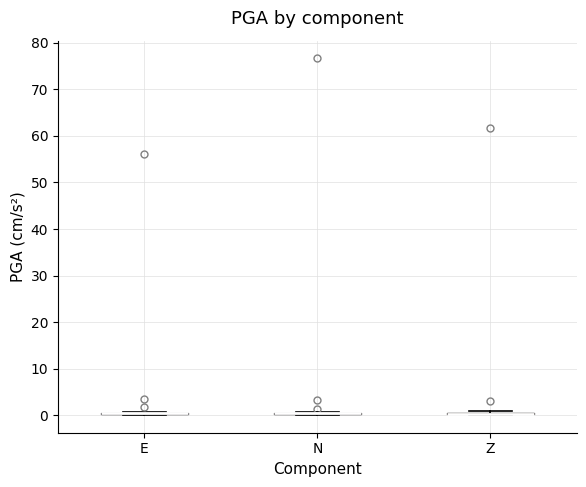

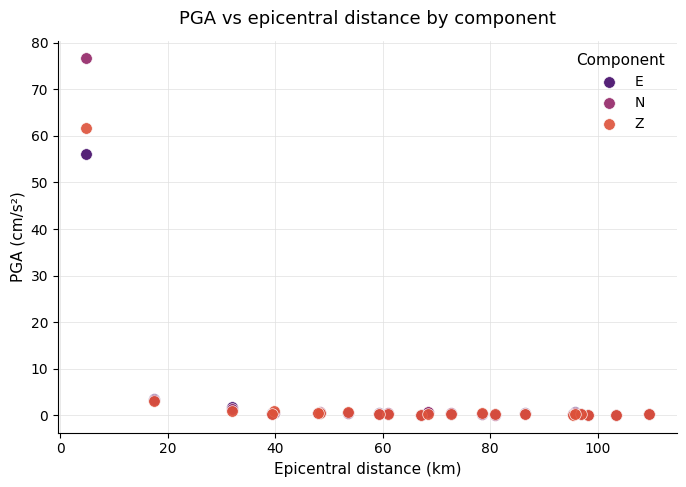

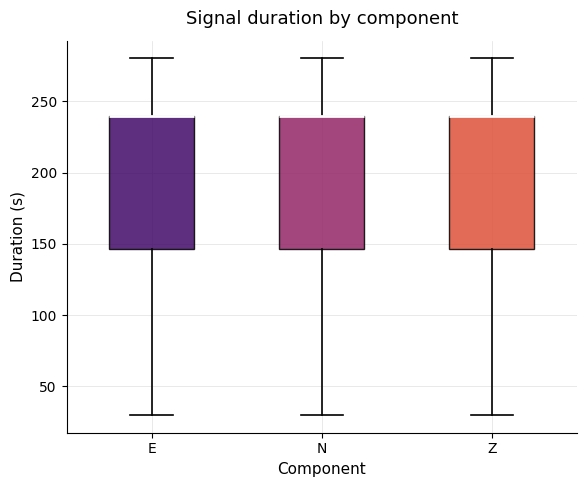

In [15]:
# 1. PGA by component
fig, ax = plt.subplots(figsize=(6, 5))
comp_data = [df_meta_var[df_meta_var['COMPONENT'] == c]['PGA_CM/S^2'].dropna().values for c in components]
bp = ax.boxplot(comp_data, tick_labels=components, patch_artist=True, widths=0.5,
                medianprops={'color': 'white', 'linewidth': 2},
                whiskerprops={'linewidth': 1.2},
                capprops={'linewidth': 1.2},
                flierprops={'marker': 'o', 'markersize': 5, 'markeredgecolor': 'gray', 'markerfacecolor': 'none'})
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(comp_colors[i])
    patch.set_alpha(0.85)

ax.set_xlabel('Component')
ax.set_ylabel('PGA (cm/s²)')
ax.set_title('PGA by component')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pga_by_component.pdf', bbox_inches='tight')
plt.show()

# 2. PGA vs epicentral distance by component
fig, ax = plt.subplots(figsize=(7, 5))
for i, comp in enumerate(components):
    subset = df_meta_var[df_meta_var['COMPONENT'] == comp]
    ax.scatter(
        subset['EPICENTRAL_DISTANCE_KM'],
        subset['PGA_CM/S^2'],
        color=comp_colors[i],
        edgecolors='white',
        linewidths=0.5,
        s=70,
        label=comp,
        alpha=0.9,
        zorder=5
    )
ax.set_xlabel('Epicentral distance (km)')
ax.set_ylabel('PGA (cm/s²)')
ax.set_title('PGA vs epicentral distance by component')
ax.legend(title='Component')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pga_vs_distance_by_component.pdf', bbox_inches='tight')
plt.show()

# 3. Signal duration by component
fig, ax = plt.subplots(figsize=(6, 5))
dur_data = [df_meta_var[df_meta_var['COMPONENT'] == c]['DURATION_S'].dropna().values for c in components]
bp2 = ax.boxplot(dur_data, tick_labels=components, patch_artist=True, widths=0.5,
                 medianprops={'color': 'white', 'linewidth': 2},
                 whiskerprops={'linewidth': 1.2},
                 capprops={'linewidth': 1.2},
                 flierprops={'marker': 'o', 'markersize': 5, 'markeredgecolor': 'gray', 'markerfacecolor': 'none'})
for i, patch in enumerate(bp2['boxes']):
    patch.set_facecolor(comp_colors[i])
    patch.set_alpha(0.85)

ax.set_xlabel('Component')
ax.set_ylabel('Duration (s)')
ax.set_title('Signal duration by component')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'duration_by_component.pdf', bbox_inches='tight')
plt.show()

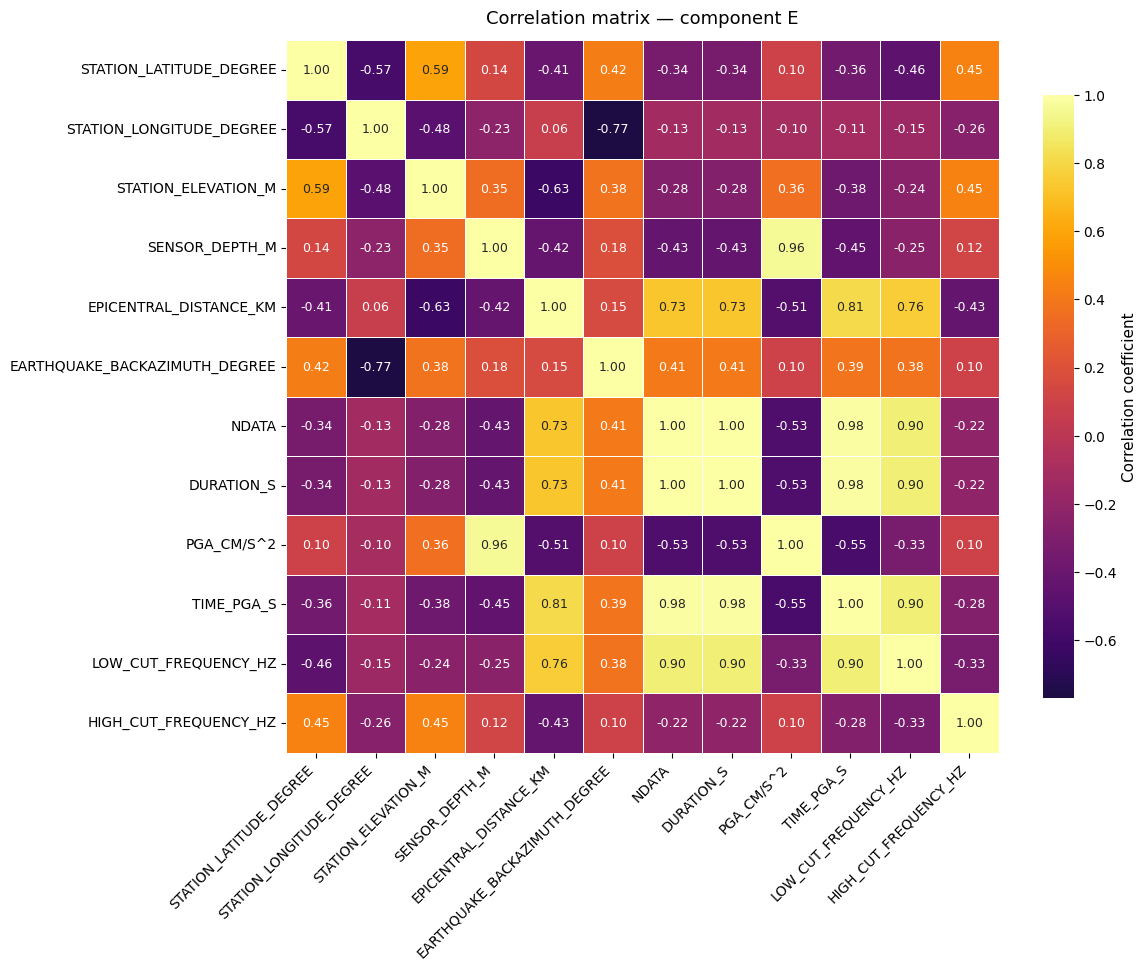

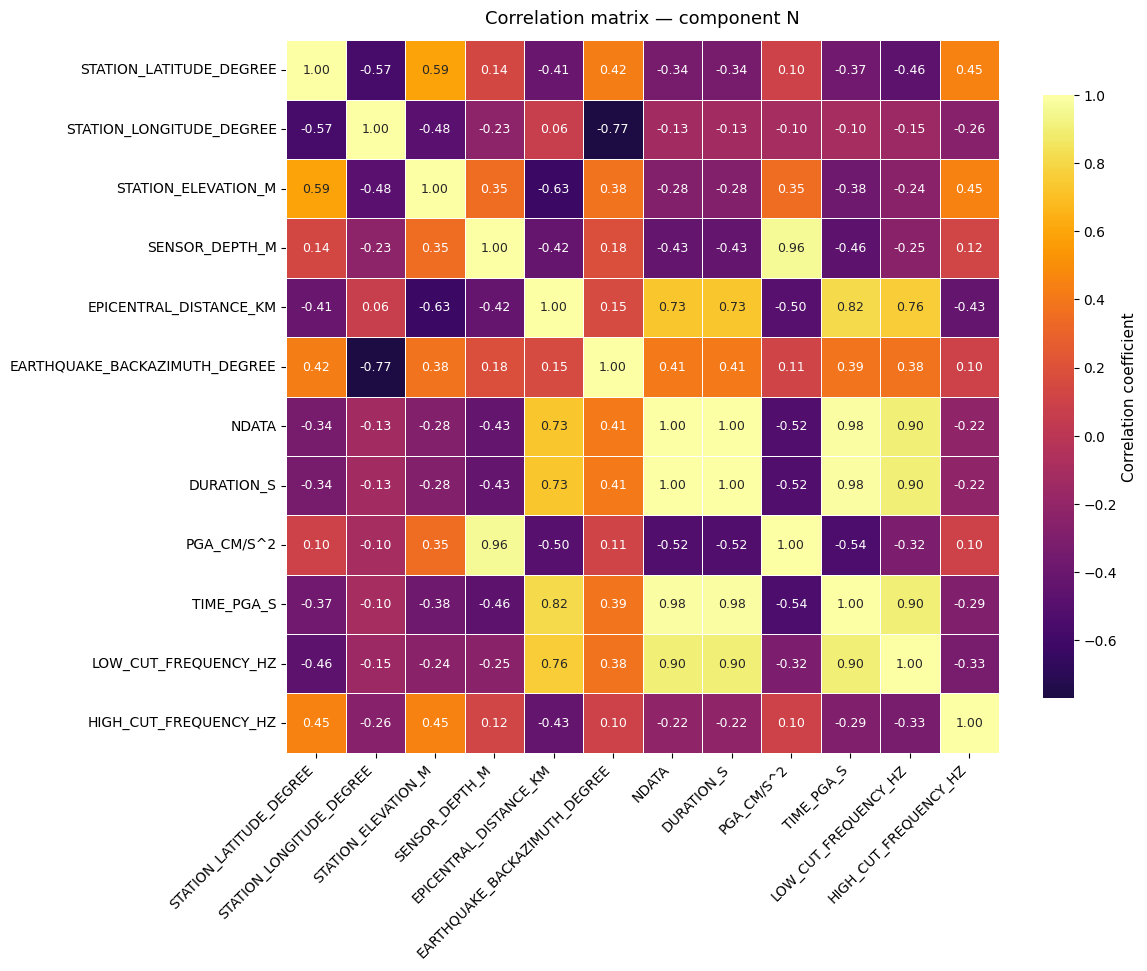

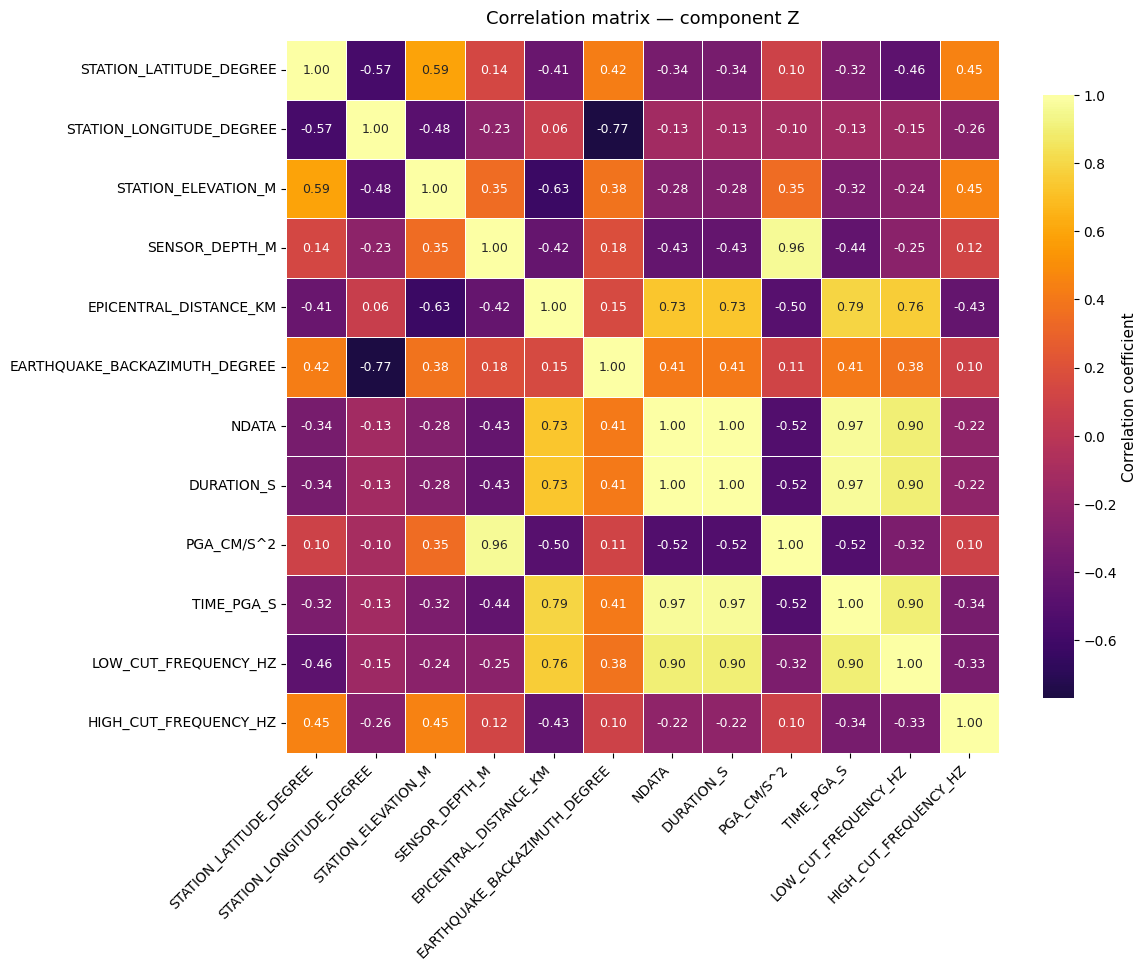

In [16]:
for comp in ['E', 'N', 'Z']:
    subset = df_meta_var[df_meta_var['COMPONENT'] == comp]
    corr = subset.select_dtypes(include=['float64', 'int64']).corr().round(2)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='inferno',
        center=0,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        annot_kws={'size': 9},
        square=True,
        cbar_kws={'shrink': 0.8, 'label': 'Correlation coefficient'}
    )
    ax.grid(False)
    ax.set_title(f'Correlation matrix — component {comp}')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'correlation_matrix_{comp}.pdf', bbox_inches='tight')
    plt.show()

## 6.5 Epicentral distance analysis

In [17]:
# Divide stations into 3 equal groups by epicentral distance
df_stations = df_meta_clean.drop_duplicates('STATION_CODE')[['STATION_CODE', 'EPICENTRAL_DISTANCE_KM']].sort_values('EPICENTRAL_DISTANCE_KM')
df_stations['DISTANCE_GROUP'] = pd.qcut(
    df_stations['EPICENTRAL_DISTANCE_KM'],
    q=3,
    labels=['Near', 'Mid', 'Far']
)

print(df_stations.groupby('DISTANCE_GROUP', observed=True)['EPICENTRAL_DISTANCE_KM'].describe())
print("\nStations per group:")
print(df_stations.groupby('DISTANCE_GROUP', observed=True)['STATION_CODE'].apply(list))

# Merge back into df_meta_var
df_meta_var = df_meta_var.merge(
    df_stations[['STATION_CODE', 'DISTANCE_GROUP']],
    on='STATION_CODE',
    how='left'
)

# Setup
groups = ['Near', 'Mid', 'Far']
group_colors = [colors[0], colors[1], colors[2]]

                count       mean        std   min   25%    50%   75%    max
DISTANCE_GROUP                                                             
Near              7.0  32.828571  16.272442   4.8  24.7  39.40  43.9   48.4
Mid               7.0  65.771429   8.502885  53.5  60.1  67.20  70.5   78.5
Far               8.0  95.787500   8.952005  80.9  93.1  96.25  99.5  109.5

Stations per group:
DISTANCE_GROUP
Near              [SURF, BRZ, CRI, OGAG, ISO, SAV, BHB]
Mid            [SLZ, SPIF, MFC, OGDI, OGSA, MVIF, OGMO]
Far     [SAOF, ESCA, REVF, MENA, CAGN, MON, OGS3, EILF]
Name: STATION_CODE, dtype: object


### Correlation analysis by distance group

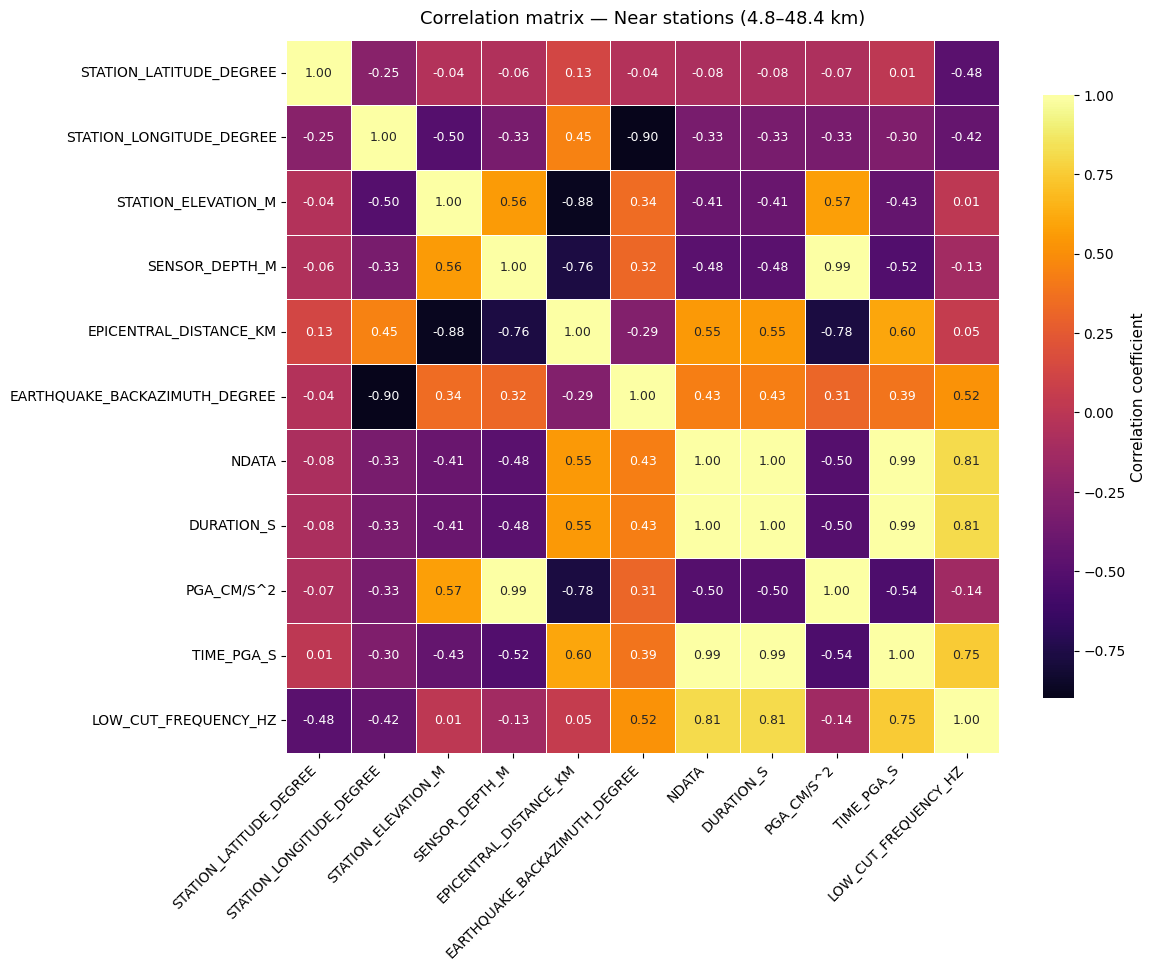

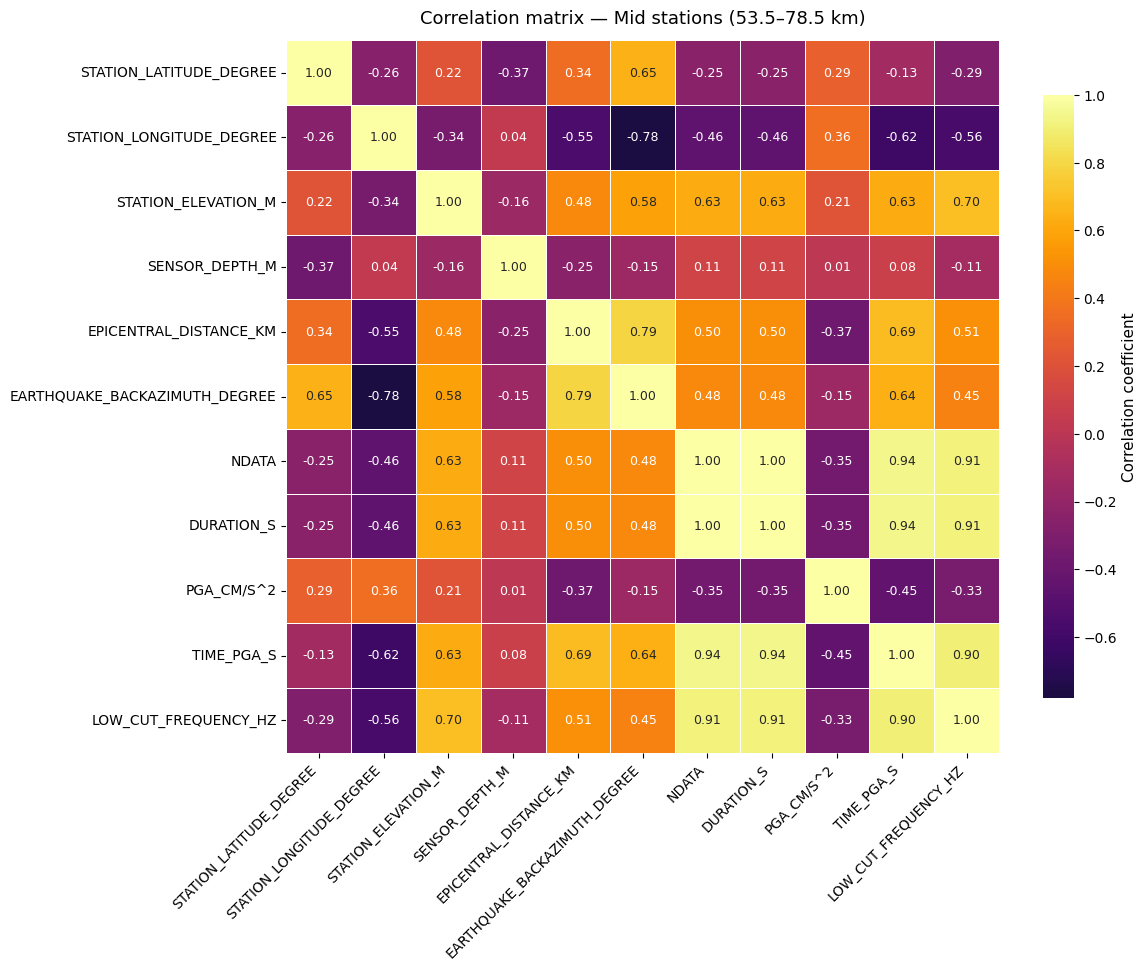

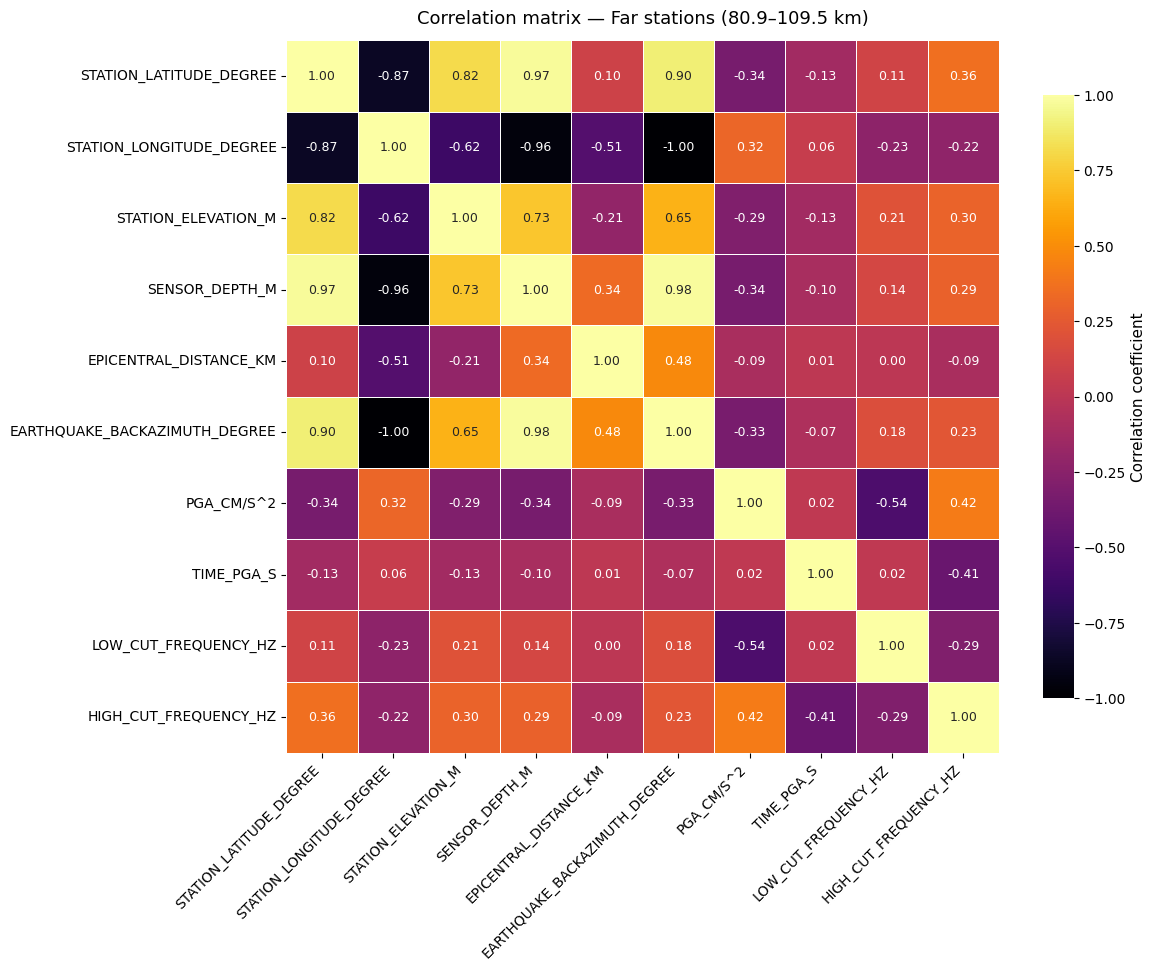

In [18]:
corr_matrices = {}
for i, group in enumerate(groups):
    stations_in_group = df_stations[df_stations['DISTANCE_GROUP'] == group]['STATION_CODE'].values
    df_group = df_meta_var[df_meta_var['STATION_CODE'].isin(stations_in_group)]
    
    dist_min = df_group['EPICENTRAL_DISTANCE_KM'].min()
    dist_max = df_group['EPICENTRAL_DISTANCE_KM'].max()
    
    numeric_df = df_group.select_dtypes(include=['float64', 'int64'])
    numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]
    corr = numeric_df.corr().round(2)
    
    # Save for later use
    corr_matrices[group] = corr
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='inferno',
        center=0,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        annot_kws={'size': 9},
        square=True,
        cbar_kws={'shrink': 0.8, 'label': 'Correlation coefficient'}
    )
    ax.grid(False)
    ax.set_title(f'Correlation matrix — {group} stations ({dist_min}–{dist_max} km)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'correlation_matrix_{group.lower()}.pdf', bbox_inches='tight')
    plt.show()

### Correlation matrix differences by distance group

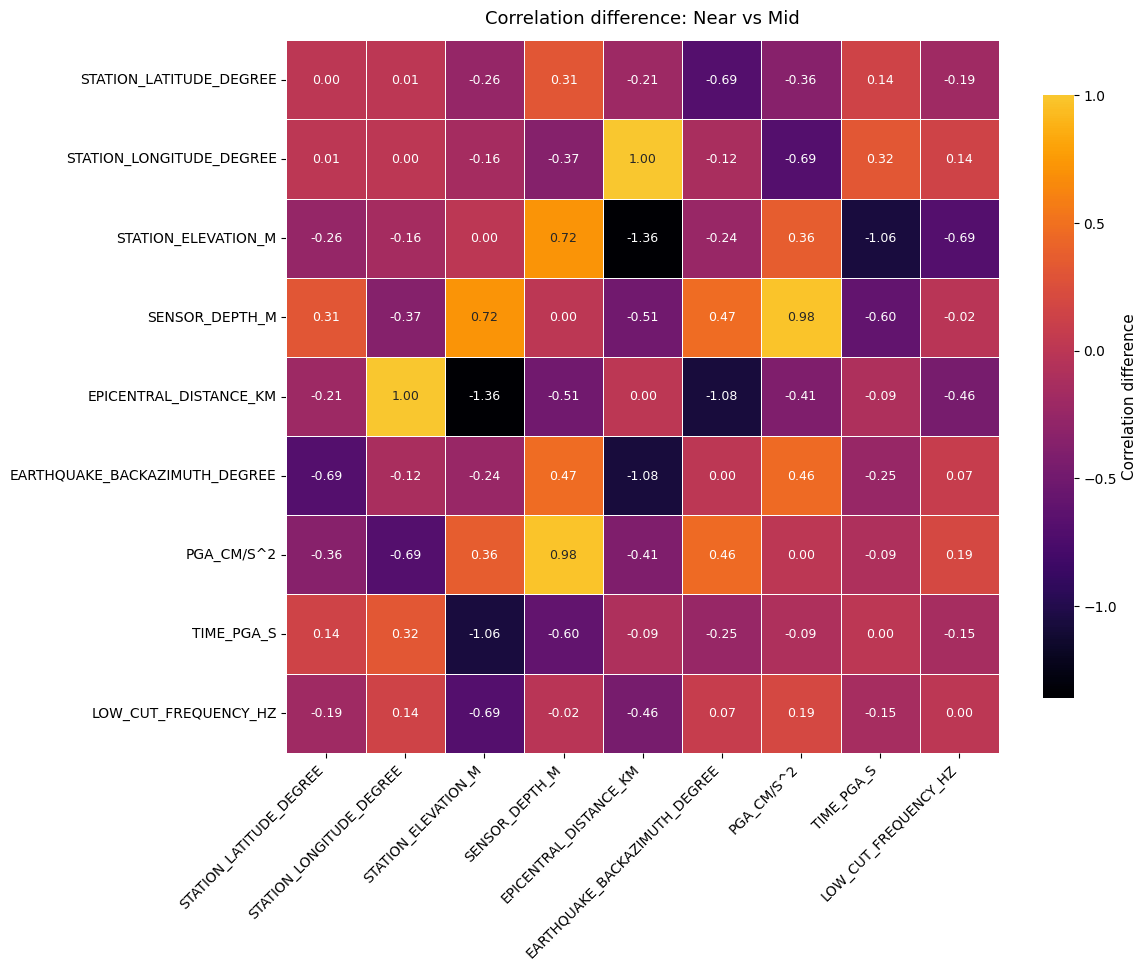

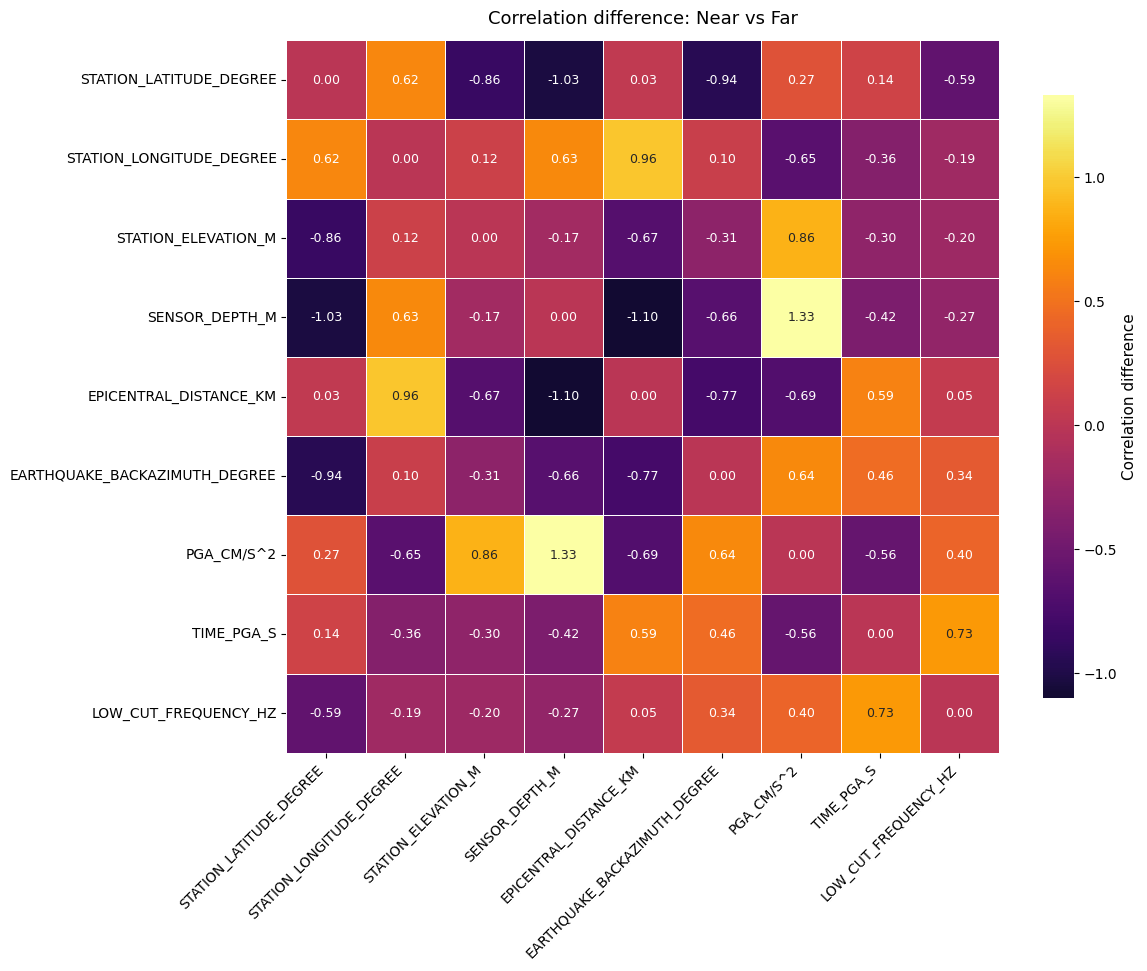

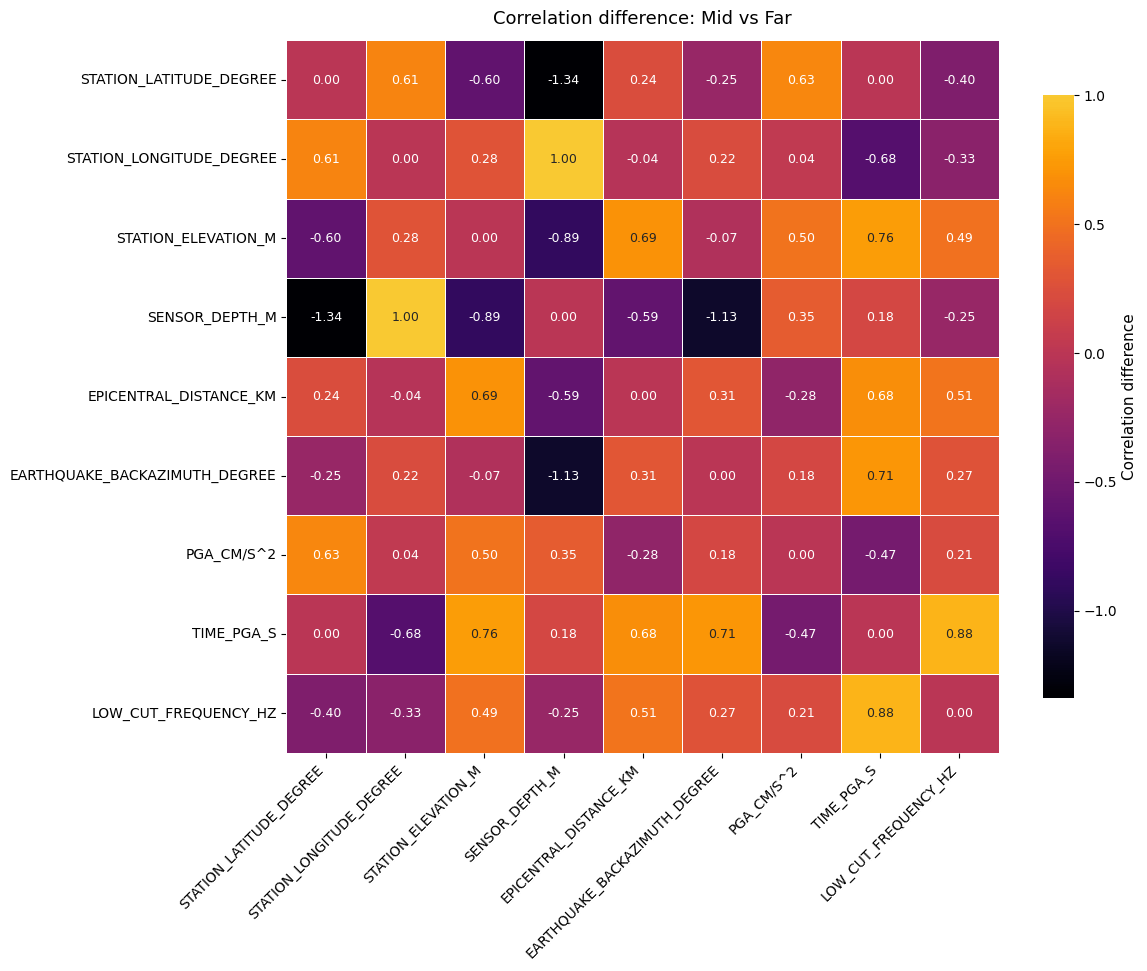

In [19]:
# Find common columns across all groups
common_cols = corr_matrices['Near'].columns
for group in groups:
    common_cols = common_cols.intersection(corr_matrices[group].columns)

group_pairs = list(combinations(groups, 2))

for g1, g2 in group_pairs:
    diff = (corr_matrices[g1].loc[common_cols, common_cols] -
            corr_matrices[g2].loc[common_cols, common_cols]).round(2)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        diff,
        annot=True,
        fmt='.2f',
        cmap='inferno',
        center=0,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        annot_kws={'size': 9},
        square=True,
        cbar_kws={'shrink': 0.8, 'label': 'Correlation difference'}
    )
    ax.grid(False)
    ax.set_title(f'Correlation difference: {g1} vs {g2}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'corr_diff_{g1.lower()}_{g2.lower()}.pdf', bbox_inches='tight')
    plt.show()

### Statistical significance of correlation differences

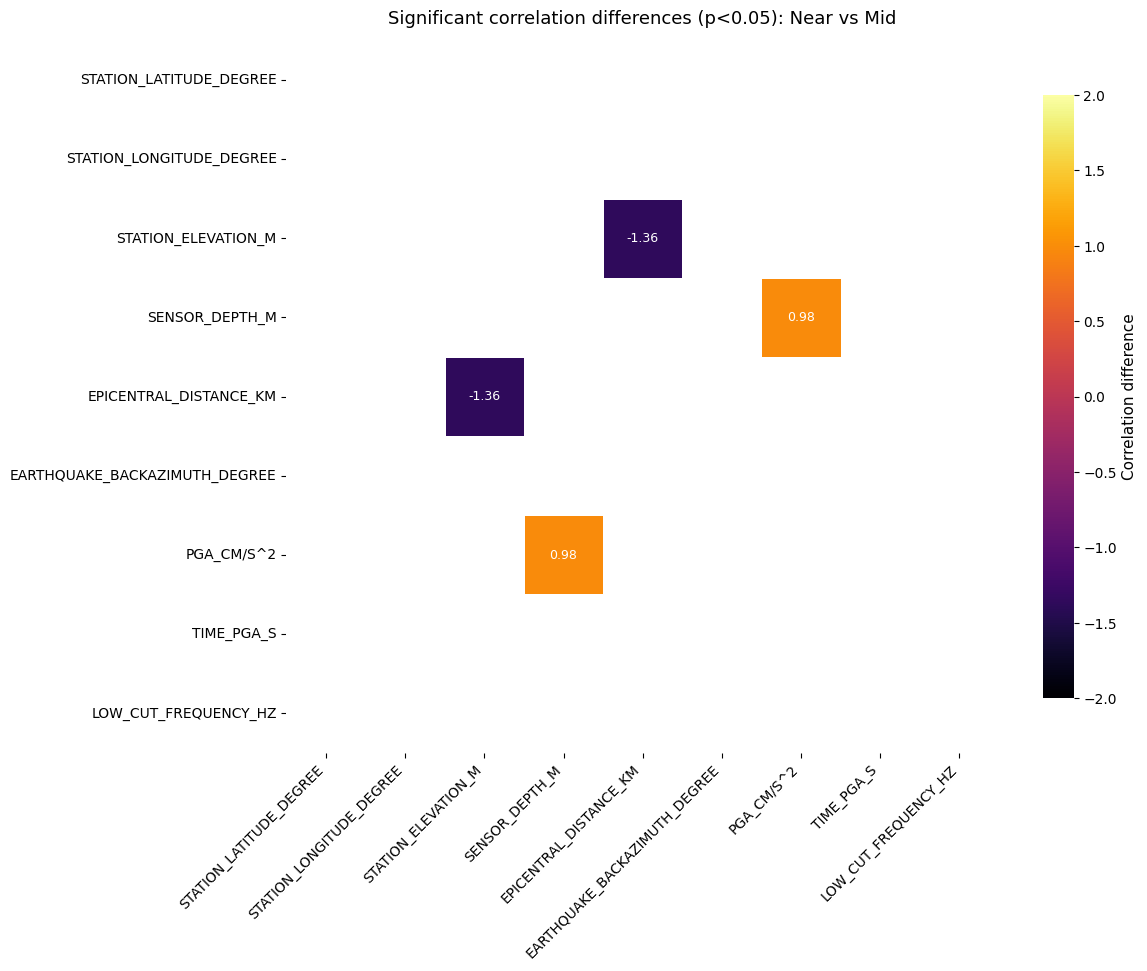

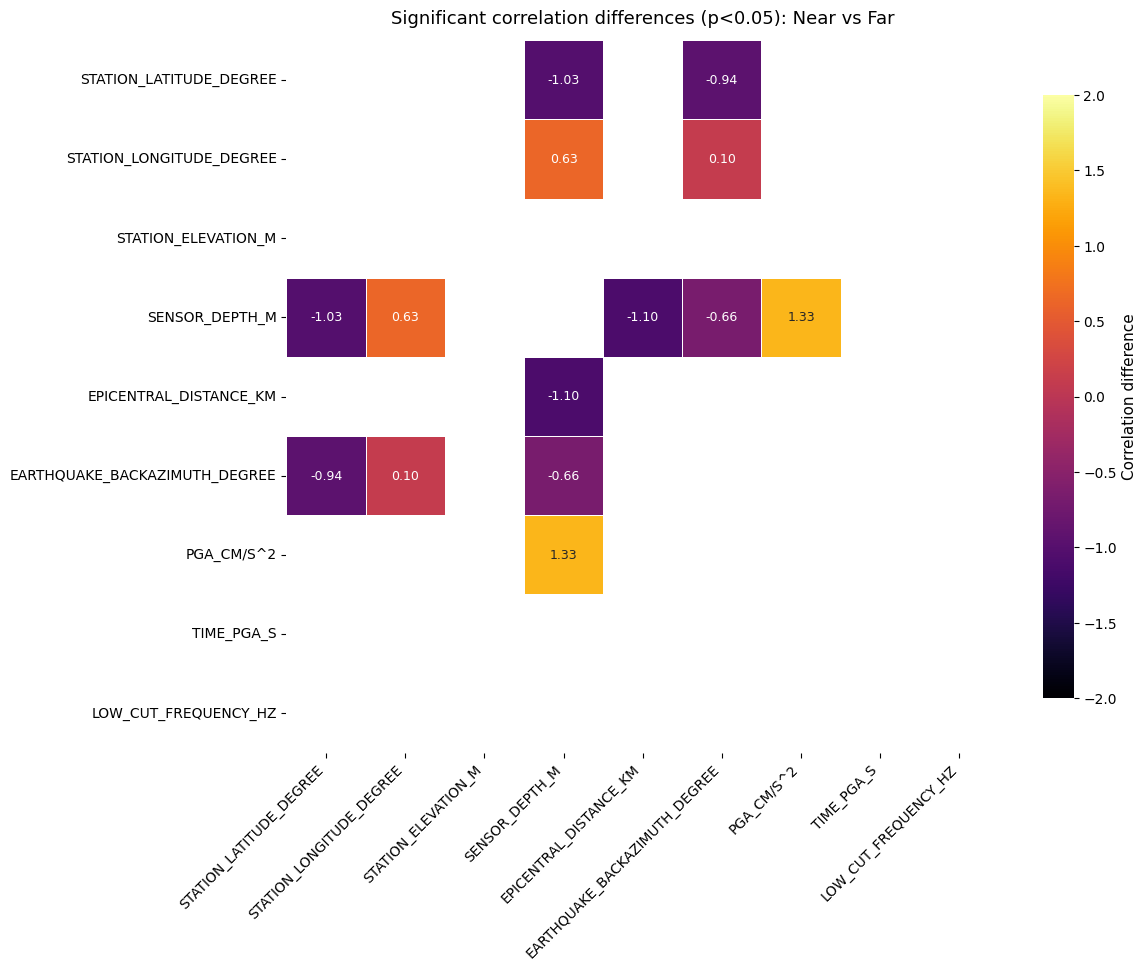

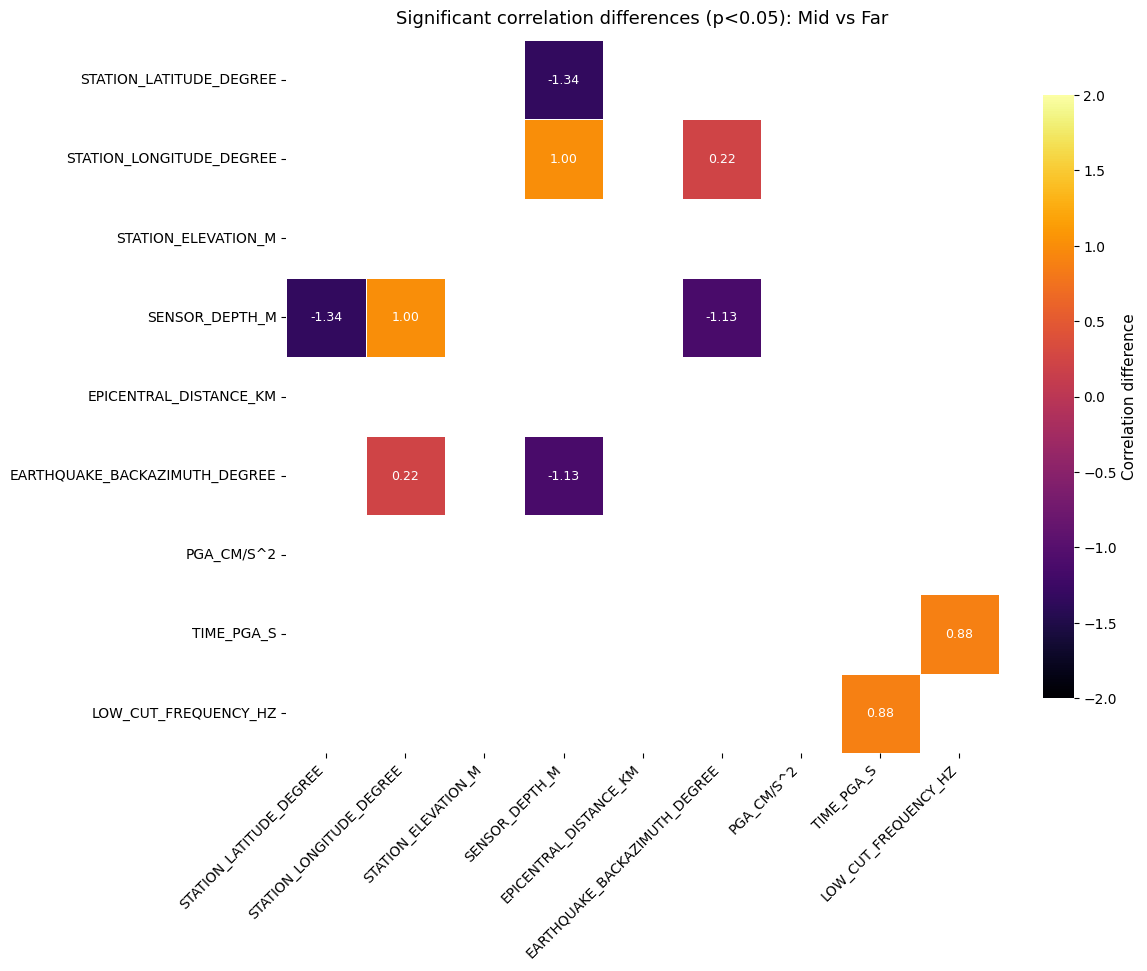

In [20]:
def fisher_z_test(r1, r2, n1, n2):
    """Test if two correlation coefficients are significantly different
    using Fisher's z-transformation."""
    # Fisher z-transformation
    z1 = np.arctanh(np.clip(r1, -0.9999, 0.9999))
    z2 = np.arctanh(np.clip(r2, -0.9999, 0.9999))
    
    # Standard error
    se = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    
    # z-score and p-value (two-tailed)
    z = (z1 - z2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return p_value

# Sample sizes per group
n_per_group = {group: len(df_stations[df_stations['DISTANCE_GROUP'] == group]) for group in groups}

alpha = 0.05

for g1, g2 in group_pairs:
    n1 = n_per_group[g1]
    n2 = n_per_group[g2]
    
    # Compute p-values matrix
    p_matrix = pd.DataFrame(index=common_cols, columns=common_cols, dtype=float)
    for col1 in common_cols:
        for col2 in common_cols:
            r1 = corr_matrices[g1].loc[col1, col2]
            r2 = corr_matrices[g2].loc[col1, col2]
            p_matrix.loc[col1, col2] = fisher_z_test(r1, r2, n1, n2)

    # Mask non-significant differences
    significant = p_matrix < alpha

    fig, ax = plt.subplots(figsize=(12, 10))
    diff = (corr_matrices[g1].loc[common_cols, common_cols] -
            corr_matrices[g2].loc[common_cols, common_cols]).round(2)
    
    sns.heatmap(
        diff,
        annot=True,
        fmt='.2f',
        cmap='inferno',
        center=0,
        vmin=-2,
        vmax=2,
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        annot_kws={'size': 9},
        square=True,
        cbar_kws={'shrink': 0.8, 'label': 'Correlation difference'},
        mask=~significant  # show only significant differences
    )
    ax.grid(False)
    ax.set_title(f'Significant correlation differences (p<{alpha}): {g1} vs {g2}')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.tick_params(axis='y', rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'corr_diff_significant_{g1.lower()}_{g2.lower()}.pdf', bbox_inches='tight')
    plt.show()

In [21]:
# Build summary table of significant differences
rows = []
for g1, g2 in group_pairs:
    n1 = n_per_group[g1]
    n2 = n_per_group[g2]
    
    for col1 in common_cols:
        for col2 in common_cols:
            if col1 >= col2:  # avoid duplicates (symmetric matrix)
                continue
            r1 = corr_matrices[g1].loc[col1, col2]
            r2 = corr_matrices[g2].loc[col1, col2]
            p = fisher_z_test(r1, r2, n1, n2)
            diff_val = round(r1 - r2, 2)
            
            if p < alpha:
                rows.append({
                    'Comparison': f'{g1} vs {g2}',
                    'Variable 1': col1,
                    'Variable 2': col2,
                    'Corr. diff.': diff_val,
                    'p-value': round(p, 4)
                })

df_significant = pd.DataFrame(rows).sort_values(
    ['Comparison', 'Corr. diff.'],
    ascending=[True, False],
    key=lambda x: x.abs() if x.dtype != 'object' else x
)

# Generate LaTeX code
latex_rows = []
for _, row in df_significant.iterrows():
    latex_rows.append(
        f"{row['Comparison']} & {row['Variable 1']} & {row['Variable 2']} & {row['Corr. diff.']} & {row['p-value']} \\\\"
    )

latex_table = r"""
\begin{table}[H]
\centering
\caption{Statistically significant correlation differences by distance group (p < 0.05)}
\label{tab:corr_diff}
\begin{tabular}{lllrr}
\toprule
Comparison & Variable 1 & Variable 2 & Corr. diff. & p-value \\
\midrule
""" + "\n".join(latex_rows) + r"""
\bottomrule
\end{tabular}
\end{table}
"""

print("\nLaTeX code:")
print(latex_table)


LaTeX code:

\begin{table}[H]
\centering
\caption{Statistically significant correlation differences by distance group (p < 0.05)}
\label{tab:corr_diff}
\begin{tabular}{lllrr}
\toprule
Comparison & Variable 1 & Variable 2 & Corr. diff. & p-value \\
\midrule
Mid vs Far & SENSOR_DEPTH_M & STATION_LATITUDE_DEGREE & -1.34 & 0.0002 \\
Mid vs Far & EARTHQUAKE_BACKAZIMUTH_DEGREE & SENSOR_DEPTH_M & -1.13 & 0.0003 \\
Mid vs Far & SENSOR_DEPTH_M & STATION_LONGITUDE_DEGREE & 1.0 & 0.0031 \\
Mid vs Far & LOW_CUT_FREQUENCY_HZ & TIME_PGA_S & 0.88 & 0.0304 \\
Mid vs Far & EARTHQUAKE_BACKAZIMUTH_DEGREE & STATION_LONGITUDE_DEGREE & 0.22 & 0.0 \\
Near vs Far & PGA_CM/S^2 & SENSOR_DEPTH_M & 1.33 & 0.0 \\
Near vs Far & EPICENTRAL_DISTANCE_KM & SENSOR_DEPTH_M & -1.1 & 0.0441 \\
Near vs Far & SENSOR_DEPTH_M & STATION_LATITUDE_DEGREE & -1.03 & 0.0013 \\
Near vs Far & EARTHQUAKE_BACKAZIMUTH_DEGREE & STATION_LATITUDE_DEGREE & -0.94 & 0.0242 \\
Near vs Far & EARTHQUAKE_BACKAZIMUTH_DEGREE & SENSOR_DEPTH_M & -0.6

In [22]:
display(df_significant.style
    .format({'Corr. diff.': '{:.2f}', 'p-value': '{:.4f}'})
    .set_caption('Statistically significant correlation differences by distance group (p < 0.05)')
    .background_gradient(subset=['Corr. diff.'], cmap='inferno')
)

,Comparison,Variable 1,Variable 2,Corr. diff.,p-value
9,Mid vs Far,SENSOR_DEPTH_M,STATION_LATITUDE_DEGREE,-1.34,0.0002
12,Mid vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,SENSOR_DEPTH_M,-1.13,0.0003
10,Mid vs Far,SENSOR_DEPTH_M,STATION_LONGITUDE_DEGREE,1.00,0.0031
13,Mid vs Far,LOW_CUT_FREQUENCY_HZ,TIME_PGA_S,0.88,0.0304
11,Mid vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,STATION_LONGITUDE_DEGREE,0.22,0.0000
8,Near vs Far,PGA_CM/S^2,SENSOR_DEPTH_M,1.33,0.0000
4,Near vs Far,EPICENTRAL_DISTANCE_KM,SENSOR_DEPTH_M,-1.10,0.0441
2,Near vs Far,SENSOR_DEPTH_M,STATION_LATITUDE_DEGREE,-1.03,0.0013
5,Near vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,STATION_LATITUDE_DEGREE,-0.94,0.0242
7,Near vs Far,EARTHQUAKE_BACKAZIMUTH_DEGREE,SENSOR_DEPTH_M,-0.66,0.0034


### PGA correlation with numerical variables by distance group

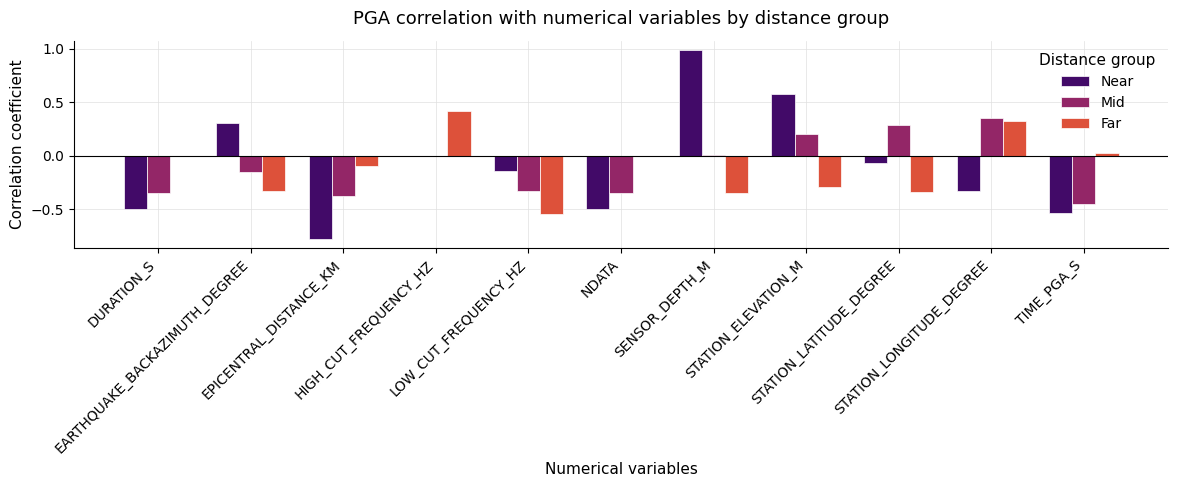

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

# Compute PGA correlation with all other numeric columns for each group
pga_corrs = {}
for group in groups:
    stations_in_group = df_stations[df_stations['DISTANCE_GROUP'] == group]['STATION_CODE'].values
    df_group = df_meta_var[df_meta_var['STATION_CODE'].isin(stations_in_group)]
    numeric_df = df_group.select_dtypes(include=['float64', 'int64'])
    numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]
    corr = numeric_df.corr()['PGA_CM/S^2'].drop('PGA_CM/S^2')
    pga_corrs[group] = corr

df_pga_corr = pd.DataFrame(pga_corrs)

# Bar plot
x = range(len(df_pga_corr))
width = 0.25

for i, group in enumerate(groups):
    ax.bar(
        [xi + i * width for xi in x],
        df_pga_corr[group],
        width=width,
        label=group,
        color=group_colors[i],
        edgecolor='white',
        linewidth=0.5
    )

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(df_pga_corr.index, rotation=45, ha='right')
ax.set_xlabel('Numerical variables')
ax.set_ylabel('Correlation coefficient')
ax.set_title('PGA correlation with numerical variables by distance group')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(title='Distance group')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pga_correlation_by_distance.pdf', bbox_inches='tight')
plt.show()